# GMM — 가우시안 혼합 모델 클러스터링 (탐색/프로토타입)

**프로젝트:** HeatGuardAI — 서울시 폭염 대응 쿨링포그 설치 추천 시스템

**목적:** 점수화된 피처로 GMM 클러스터링을 수행하고, 한강 격자를 제거한 클린 데이터를 생성합니다.

**파이프라인:**
1. 데이터 로드 · 피처 선택
2. BIC 기반 최적 클러스터 수(K) 탐색
3. GMM 학습 · 클러스터 예측 · 이름 부여
4. 클러스터 특성 분석 (프로파일, Pairplot)
5. Folium 지도 시각화
6. 한강 격자 제거 (공간 조인)
7. 클린 데이터 CSV 저장

**입력:** `data/processed/heatguard_cell_feature_scored.csv`
**출력:** `data/processed/heatguard_cell_feature_scored_clean.csv`

## GMM 개요

**GMM(Gaussian Mixture Model)**은 데이터가 여러 개의 가우시안 분포가 혼합된 형태로 분포되어 있다고 가정하는 확률 모델입니다.

| 특징 | 설명 |
|------|------|
| **확률적 클러스터링** | 각 데이터가 특정 클러스터에 속할 확률을 제공합니다 |
| **유연한 클러스터 형태** | K-평균이 원형 가정인 반면, GMM은 타원형 등 다양한 형태 지원 |
| **EM 알고리즘** | 기댓값-최대화 알고리즘으로 파라미터(평균, 공분산 등)를 추정합니다 |

## 0. 라이브러리 · 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ── 전역 설정 ──
DATA_PATH   = "../data_processed/processed/merged/heatguard_cell_feature_scored.csv"
OUTPUT_PATH = "../data_processed/processed/merged/heatguard_cell_feature_scored_clean.csv"

SCORE_COLS = ["suhii_score", "apparent_temp_score", "bus_flow_score", "ndvi_score"]

OPTIMAL_K   = 3          # BIC 분석 후 결정
COV_TYPE    = "diag"
RANDOM_STATE = 42

CLUSTER_NAME_MAP = {
    0: "자연 완화형 관리 지역",
    1: "폭염 고온 핵심 개입 지역",
    2: "유동인구 체감온도 고위험 지역",
}

CLUSTER_COLORS = {
    0: "#2ecc71",   # 자연 완화형 (초록)
    1: "#e74c3c",   # 폭염 고온 핵심 (빨강)
    2: "#f1c40f",   # 유동인구 고위험 (노랑)
}

## 1. 데이터 로드 및 피처 선택

In [3]:
df = pd.read_csv(DATA_PATH)

X = df[SCORE_COLS].dropna()
print(f"행 수: {len(X):,} | 피처: {SCORE_COLS}")
X.head()

행 수: 91,765 | 피처: ['suhii_score', 'apparent_temp_score', 'bus_flow_score', 'ndvi_score']


,suhii_score,apparent_temp_score,bus_flow_score,ndvi_score
0,0.511384,0.593023,0.658269,0.518903
1,0.564623,0.593023,0.657479,0.362348
2,0.602797,0.593023,0.656581,0.336099
3,0.314329,0.585271,0.678467,0.716965
4,0.314469,0.585271,0.678324,0.719887


## 2. 최적 클러스터 수 탐색 (BIC)

BIC(Bayesian Information Criterion) 값이 가장 낮은 K가 최적입니다.
그래프에서 기울기가 완만해지는 **엘보우(elbow)** 지점을 찾습니다.

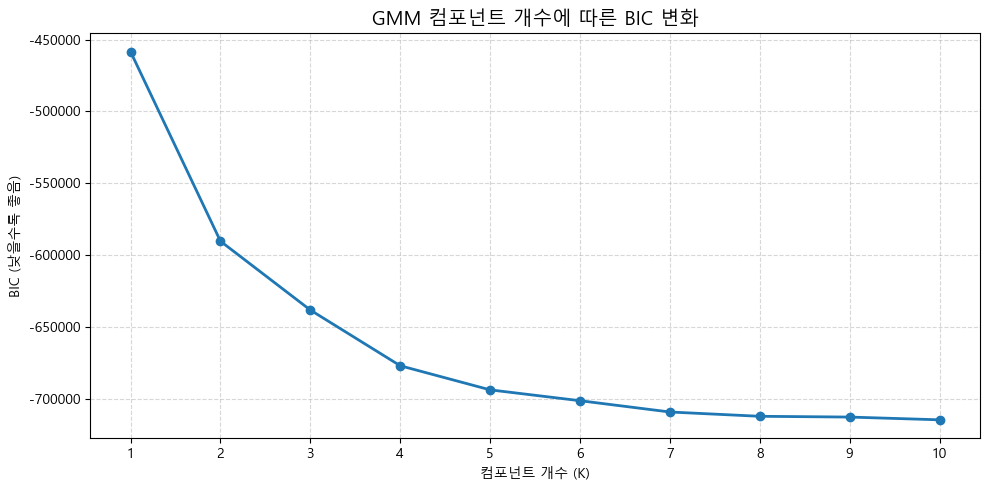


BIC 최소: K=10
선택된 K: 3 (해석 가능성 고려)


In [4]:
# ── BIC 계산 (K=1~10) ──
bic_results = []
for n in range(1, 11):
    gmm = GaussianMixture(n_components=n, covariance_type=COV_TYPE, n_init=1, random_state=RANDOM_STATE)
    gmm.fit(X)
    bic_results.append({"n_components": n, "bic": gmm.bic(X)})

df_bic = pd.DataFrame(bic_results)

# ── 시각화 ──
plt.figure(figsize=(10, 5), facecolor="white")
plt.plot(df_bic["n_components"], df_bic["bic"], marker="o", linewidth=2)
plt.title("GMM 컴포넌트 개수에 따른 BIC 변화", fontsize=14)
plt.xlabel("컴포넌트 개수 (K)")
plt.ylabel("BIC (낮을수록 좋음)")
plt.xticks(df_bic["n_components"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nBIC 최소: K={df_bic.loc[df_bic['bic'].idxmin(), 'n_components']:.0f}")
print(f"선택된 K: {OPTIMAL_K} (해석 가능성 고려)")

## 3. GMM 클러스터링 수행

In [5]:
# ── GMM 학습 및 예측 ──
gmm = GaussianMixture(n_components=OPTIMAL_K, covariance_type=COV_TYPE, random_state=RANDOM_STATE)
gmm.fit(X)
labels = gmm.predict(X)

# ── 결과를 원본 df에 병합 ──
df_clustered = df.loc[X.index].copy()
df_clustered["cluster"] = labels
df_clustered["cluster_name"] = df_clustered["cluster"].map(CLUSTER_NAME_MAP)

print(f"{OPTIMAL_K}개 클러스터로 분류 완료")
print(df_clustered["cluster"].value_counts().sort_index())

3개 클러스터로 분류 완료
cluster
0    21783
1    28620
2    41362
Name: count, dtype: int64


## 4. 클러스터 특성 분석

각 클러스터의 평균 피처 값을 통해 그 특성을 해석합니다.

| 클러스터 | 이름 | 핵심 특징 |
|----------|------|-----------|
| 0 | 자연 완화형 관리 지역 | NDVI 높고, 취약인구 낮은 쾌적 지역 |
| 1 | 폭염 고온 핵심 개입 지역 | SUHII·체감온도 높은 열섬 핵심 |
| 2 | 유동인구 체감온도 고위험 지역 | 유동인구·취약인구 밀집 |

In [6]:
# ── 클러스터 프로파일 ──
cluster_profile = df_clustered.groupby("cluster")[SCORE_COLS].mean().round(3)
print("클러스터별 평균 피처:")
cluster_profile

클러스터별 평균 피처:


,suhii_score,apparent_temp_score,bus_flow_score,ndvi_score
cluster,,,,
0,0.429,0.438,0.619,0.839
1,0.671,0.542,0.644,0.549
2,0.644,0.552,0.684,0.486


## 5. 시각화 — Pair Plot

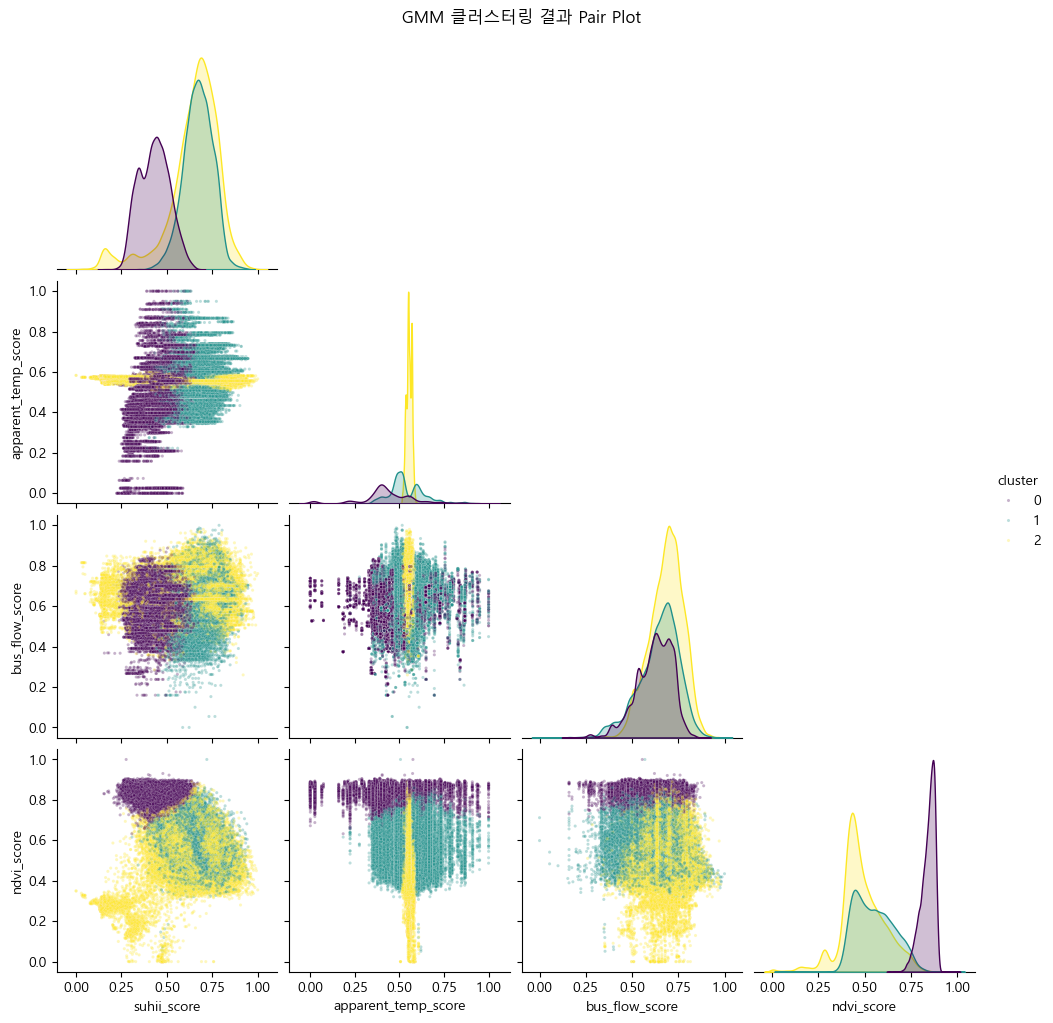

In [7]:
sns.pairplot(
    df_clustered, hue="cluster", vars=SCORE_COLS,
    palette="viridis", corner=True, plot_kws={"s": 5, "alpha": 0.3}
)
plt.suptitle("GMM 클러스터링 결과 Pair Plot", y=1.02)
plt.show()

## 6. Folium 지도 시각화 (한강 제거 전)

In [ ]:
import folium

seoul_center = [37.5665, 126.9780]
df_plot = df_clustered.sample(frac=0.3, random_state=42)

m = folium.Map(location=seoul_center, zoom_start=11, tiles="cartodbpositron")
for c_id, group in df_plot.groupby("cluster"):
    fg = folium.FeatureGroup(name=f"Cluster {c_id}")
    for _, row in group.iterrows():
        folium.CircleMarker(
            location=[row["center_lat"], row["center_lon"]],
            radius=3,
            color=CLUSTER_COLORS[c_id],
            fill=True, fill_opacity=0.7,
        ).add_to(fg)
    fg.add_to(m)
folium.LayerControl().add_to(m)
m

## 7. 한강 격자 제거 (공간 조인)

한강 위에 위치한 격자 포인트를 Shapefile 기반 공간 조인으로 제거합니다.

In [9]:
import geopandas as gpd

# ── 격자 → GeoDataFrame ──
gdf = gpd.GeoDataFrame(
    df_clustered,
    geometry=gpd.points_from_xy(df_clustered["center_lon"], df_clustered["center_lat"]),
    crs="EPSG:4326",
)

# ── 강 Shapefile 로드 ──
river = gpd.read_file("../data_processed/raw/한강경계/N3A_E0032111.shp").to_crs("EPSG:4326")

# ── 공간 조인: 강 안에 있는 격자 판별 ──
joined = gpd.sjoin(gdf, river, how="left", predicate="within")

# ── 강 밖 격자만 남기기 ──
gdf_clean = joined[joined.index_right.isna()].copy()

# ── 불필요 컬럼 제거 ──
cols_to_drop = ["geometry", "index_right", "UFID", "SCLS", "FMTA"]
df_clean = gdf_clean.drop(columns=[c for c in cols_to_drop if c in gdf_clean.columns])

print(f"제거 전: {len(df_clustered):,}행")
print(f"제거 후: {len(df_clean):,}행 (한강 격자 {len(df_clustered) - len(df_clean):,}개 제거)")

제거 전: 91,765행
제거 후: 87,936행 (한강 격자 3,829개 제거)


## 8. 필터 후 지도 · 최종 저장

In [10]:
# ── 필터 후 지도 ──
df_plot2 = df_clean.sample(frac=0.3, random_state=42)

# m2 = folium.Map(location=seoul_center, zoom_start=11, tiles="cartodbpositron")
# for c_id, group in df_plot2.groupby("cluster"):
#     fg = folium.FeatureGroup(name=f"Cluster {c_id}")
#     for _, row in group.iterrows():
#         folium.CircleMarker(
#             location=[row["center_lat"], row["center_lon"]],
#             radius=3,
#             color=CLUSTER_COLORS[c_id],
#             fill=True, fill_opacity=0.7,
#         ).add_to(fg)
#     fg.add_to(m2)
# folium.LayerControl().add_to(m2)

# ── CSV 저장 ──
df_clean.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Saved: {OUTPUT_PATH}")

# m2
df_clean.describe()

Saved: ../data_processed/processed/merged/heatguard_cell_feature_scored_clean.csv


,cell_id,center_lat,center_lon,suhii,suhii_score,apparent_temp,apparent_temp_score,bus_flow_score,ndvi,ndvi_score,vulnerable_score,cluster
count,8.793600e+04,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000,87936.000000
mean,1.413833e+12,37.538288,127.006785,4.773577,0.613174,30.175236,0.520395,0.655821,0.456915,0.601121,0.328554,1.182860
std,9.944461e+08,0.061294,0.089333,4.452485,0.138514,0.553902,0.107345,0.102514,0.248505,0.164451,0.155455,0.801939
min,1.411415e+12,37.425264,126.789567,-10.028471,0.152693,27.490000,0.000000,0.000000,-26.556906,0.000000,0.000000,0.000000
25%,1.413095e+12,37.488016,126.940484,1.734091,0.518617,29.970000,0.480620,0.594944,0.259556,0.455602,0.215664,1.000000
50%,1.413925e+12,37.534333,127.015044,5.619225,0.639481,30.280000,0.540698,0.668169,0.400877,0.559506,0.299000,1.000000
75%,1.414615e+12,37.581334,127.077028,8.087655,0.716272,30.410000,0.565891,0.727195,0.673287,0.759790,0.433154,2.000000
max,1.415945e+12,37.683778,127.196503,17.208022,1.000000,32.650000,1.000000,1.000000,1.298346,1.000000,1.000000,2.000000


In [12]:
df = pd.read_csv("../data_processed/processed/merged/heatguard_cell_feature_scored_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87936 entries, 0 to 87935
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              87936 non-null  int64  
 1   center_lat           87936 non-null  float64
 2   center_lon           87936 non-null  float64
 3   gu_name              87936 non-null  object 
 4   dong_name            87936 non-null  object 
 5   suhii                87936 non-null  float64
 6   suhii_score          87936 non-null  float64
 7   apparent_temp        87936 non-null  float64
 8   apparent_temp_score  87936 non-null  float64
 9   bus_flow_score       87936 non-null  float64
 10  ndvi                 87936 non-null  float64
 11  ndvi_score           87936 non-null  float64
 12  vulnerable_score     87936 non-null  float64
 13  cluster              87936 non-null  int64  
 14  cluster_name         87936 non-null  object 
dtypes: float64(10), int64(2), object(3)
